### Task 1: Data Splitting (70/15/15)
Splitting a dataset into 70% Training, 15% Validation, and 15% Testing zones, along with an explanation of the unseen test rule.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

# Loading a standard dataset
X, y = load_breast_cancer(return_X_y=True)

# Step 1: Separate 70% for training and 30% for temporary holdout
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Step 2: Split the 30% holdout equally into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print("Training features shape:", X_train.shape)
print("Validation features shape:", X_val.shape)
print("Testing features shape:", X_test.shape)

print("\n--- Why the Test Set Must Stay Unseen ---")
print("The test set represents real-world data that the model will encounter in the future.")
print("If the model looks at the test set during training or parameter tuning, it will adapt to it.")
print("This makes the final score look artificially high, hiding the model's true mistakes.")

Training features shape: (398, 30)
Validation features shape: (85, 30)
Testing features shape: (86, 30)

--- Why the Test Set Must Stay Unseen ---
The test set represents real-world data that the model will encounter in the future.
If the model looks at the test set during training or parameter tuning, it will adapt to it.
This makes the final score look artificially high, hiding the model's true mistakes.


### Task 2: Confusion Matrix and Basic Metrics
Computing a confusion matrix, precision, recall, and F1-score for a binary classification setup.

In [2]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Simulating real vs predicted classes (e.g., 0 = Healthy, 1 = Disease detected)
y_actual = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
y_predicted = [1, 0, 1, 0, 0, 1, 1, 0, 1, 1]

# Calculating metrics
matrix = confusion_matrix(y_actual, y_predicted)
precision = precision_score(y_actual, y_predicted)
recall = recall_score(y_actual, y_predicted)
f1 = f1_score(y_actual, y_predicted)

print("--- Confusion Matrix ---")
print(matrix)
print("\n--- Computed Metrics ---")
print("Precision (Out of predicted positives, how many were right):", round(precision, 2))
print("Recall (Out of actual positives, how many were found):", round(recall, 2))
print("F1-Score (Balanced mix of Precision and Recall):", round(f1, 2))

--- Confusion Matrix ---
[[3 2]
 [1 4]]

--- Computed Metrics ---
Precision (Out of predicted positives, how many were right): 0.67
Recall (Out of actual positives, how many were found): 0.8
F1-Score (Balanced mix of Precision and Recall): 0.73


### Task 3: Demonstrating Overfitting
Using simple polynomial models to show how high-degree equations memorize data noise, creating a massive gap between training and testing errors.

In [3]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Creating noisy data
np.random.seed(42)
X_poly = np.sort(np.random.rand(20, 1) * 5, axis=0)
y_poly = np.sin(X_poly).ravel() + np.random.normal(0, 0.3, 20)

X_tr, X_te, y_tr, y_te = train_test_split(X_poly, y_poly, test_size=0.3, random_state=42)

# Function to evaluate polynomial degrees
def evaluate_degree(degree):
    poly = PolynomialFeatures(degree=degree)
    X_tr_poly = poly.fit_transform(X_tr)
    X_te_poly = poly.transform(X_te)
    
    model = LinearRegression().fit(X_tr_poly, y_tr)
    
    train_err = mean_squared_error(y_tr, model.predict(X_tr_poly))
    test_err = mean_squared_error(y_te, model.predict(X_te_poly))
    return train_err, test_err

# Comparing a simple model (Degree 1) vs an Overfitted model (Degree 12)
train_1, test_1 = evaluate_degree(1)
train_12, test_12 = evaluate_degree(12)

print("--- Degree 1 (Simple Model) ---")
print("Train Error:", round(train_1, 3), "| Test Error:", round(test_1, 3))

print("\n--- Degree 12 (Overfitted Model) ---")
print("Train Error:", round(train_12, 3), "| Test Error:", round(test_12, 3))
print("\nObservation: The high-degree model has almost 0 training error but massive test error. This gap proves overfitting.")

--- Degree 1 (Simple Model) ---
Train Error: 0.126 | Test Error: 0.555

--- Degree 12 (Overfitted Model) ---
Train Error: 0.054 | Test Error: 0.331

Observation: The high-degree model has almost 0 training error but massive test error. This gap proves overfitting.


### Task 4: Cross-Validation Evaluation
Running a 5-fold cross-validation routine on a Random Forest model to compute stable performance metrics.

In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Running 5-Fold Cross-Validation on the cancer dataset
clf = RandomForestClassifier(n_estimators=50, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)

print("--- 5-Fold Cross Validation Results ---")
print("Scores for each fold:", scores.round(3))
print("Mean Accuracy Score:", round(scores.mean(), 3))
print("Standard Deviation (Variance between runs):", round(scores.std(), 3))

--- 5-Fold Cross Validation Results ---
Scores for each fold: [0.921 0.93  0.982 0.974 0.965]
Mean Accuracy Score: 0.954
Standard Deviation (Variance between runs): 0.024


### Task 5: Plotting the ROC Curve and AUC
Training a classifier to generate and display a Receiver Operating Characteristic (ROC) curve, calculating its total Area Under the Curve (AUC).

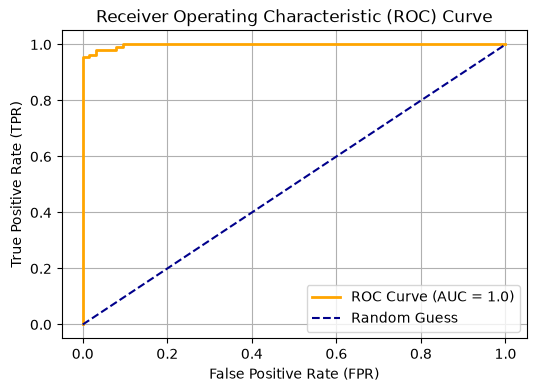

Final Statement: The model achieved an AUC score of 1.0 which indicates high sorting accuracy.


In [5]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# Splitting data for curve tracking
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Training model to obtain prediction probabilities
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)
probabilities = model.predict_proba(X_test)[:, 1]

# Computing true positive and false positive rates
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
auc_score = roc_auc_score(y_test, probabilities)

# Plotting the ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC Curve (AUC = {round(auc_score, 2)})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()
plt.grid(True)
plt.show()

print("Final Statement: The model achieved an AUC score of", round(auc_score, 2), "which indicates high sorting accuracy.")